# Morphology Label Visualization & Patch Analysis

This notebook provides visual analysis for morphology classification:

1. **Morphology Class Examples**: Side-by-side comparison of images from each morphology class
2. **Effective Radius Distribution**: Histogram of `radius_sersic` per morphology label  
3. **Patch Tokenization Visualization**: Effect of different patch sizes on galaxy images

**Morphology Labels** (`morph_flag_f150w`):
- 0: Spheroid
- 1: Disk-dominated
- 2: Irregular  
- 3: Bulge-dominated

In [1]:
import os
import sys
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.gridspec as gridspec

# Add project root to path
PROJECT_ROOT = "/u/yacheng/projects/ssl_outthere"
sys.path.insert(0, PROJECT_ROOT)

# Data paths
DATA_ROOT = "/u/yacheng/projects/ssl_outthere/images/jwst/f150w"

# Morphology label names
LABEL_NAMES = {
    0: 'Spheroid',
    1: 'Disk-dominated', 
    2: 'Irregular',
    3: 'Bulge-dominated',
}

# Colors for each class
LABEL_COLORS = {
    0: '#E74C3C',  # Red
    1: '#3498DB',  # Blue
    2: '#2ECC71',  # Green
    3: '#9B59B6',  # Purple
}

# Pixel scale conversion
# Catalog radius_sersic is in degrees, image pixel scale is 30 mas
PIXEL_SCALE_MAS = 30  # mas per pixel
DEG_TO_PIXEL = 3600 * 1000 / PIXEL_SCALE_MAS  # = 120000 pixels per degree

def radius_to_pixels(radius_deg):
    """Convert effective radius from degrees to pixels."""
    return radius_deg * DEG_TO_PIXEL

## 1. Load Data from All H5 Files

In [2]:
def load_all_data(data_root, max_per_file=None):
    """Load images and metadata from all h5 files."""
    h5_files = sorted([f for f in os.listdir(data_root) if f.endswith('.h5')])
    
    all_images = []
    all_morph_flags = []
    all_delta = []
    all_radius_sersic = []
    all_snr = []
    all_ids = []
    
    for fname in h5_files:
        fpath = os.path.join(data_root, fname)
        try:
            with h5py.File(fpath, 'r') as f:
                if 'image' not in f.keys():
                    continue
                    
                n_samples = f['image'].shape[0]
                if max_per_file and max_per_file < n_samples:
                    indices = np.sort(np.random.choice(n_samples, max_per_file, replace=False))
                else:
                    indices = np.arange(n_samples)
                
                all_images.append(f['image'][indices])
                all_morph_flags.append(f['morph_flag_f150w'][indices])
                all_delta.append(f['delta_f150w'][indices])
                all_radius_sersic.append(f['radius_sersic'][indices])
                all_snr.append(f['snr_f150w'][indices])
                all_ids.append(f['id'][indices])
                
                print(f"Loaded {len(indices)} samples from {fname}")
        except Exception as e:
            print(f"Error loading {fname}: {e}")
    
    return {
        'images': np.concatenate(all_images, axis=0),
        'morph_flag': np.concatenate(all_morph_flags, axis=0),
        'delta': np.concatenate(all_delta, axis=0),
        'radius_sersic': np.concatenate(all_radius_sersic, axis=0),
        'snr': np.concatenate(all_snr, axis=0),
        'ids': np.concatenate(all_ids, axis=0),
    }

# Load data (limit samples per file for efficiency)
print("Loading data...")
data = load_all_data(DATA_ROOT, max_per_file=5000)
print(f"\nTotal samples loaded: {len(data['images'])}")
print(f"Image shape: {data['images'][0].shape}")

Loading data...
Loaded 5000 samples from f150w_A1.h5
Loaded 5000 samples from f150w_A10.h5
Loaded 5000 samples from f150w_A2.h5
Loaded 5000 samples from f150w_A3.h5
Loaded 5000 samples from f150w_A4.h5
Loaded 5000 samples from f150w_A5.h5
Loaded 5000 samples from f150w_A6.h5
Loaded 5000 samples from f150w_A7.h5
Loaded 5000 samples from f150w_A8.h5
Loaded 5000 samples from f150w_A9.h5
Loaded 5000 samples from f150w_B1.h5
Loaded 5000 samples from f150w_B10.h5
Loaded 5000 samples from f150w_B2.h5
Loaded 5000 samples from f150w_B3.h5
Loaded 5000 samples from f150w_B4.h5
Loaded 5000 samples from f150w_B5.h5
Loaded 5000 samples from f150w_B6.h5
Loaded 5000 samples from f150w_B7.h5
Loaded 5000 samples from f150w_B8.h5
Loaded 5000 samples from f150w_B9.h5

Total samples loaded: 100000
Image shape: (128, 128)


In [3]:
# Check class distribution
print("\n=== Class Distribution ===")
for label, name in LABEL_NAMES.items():
    mask = data['morph_flag'] == label
    count = mask.sum()
    pct = 100 * count / len(data['morph_flag'])
    print(f"  {label}: {name:15s} - {count:6d} samples ({pct:.1f}%)")

# Also count NaN values
nan_count = np.isnan(data['morph_flag']).sum()
print(f"\n  NaN values: {nan_count}")


=== Class Distribution ===
  0: Spheroid        -   3675 samples (3.7%)
  1: Disk-dominated  -   2033 samples (2.0%)
  2: Irregular       -  60234 samples (60.2%)
  3: Bulge-dominated -   1192 samples (1.2%)

  NaN values: 32866


## 2. Morphology Class Examples - For Slides

Generate publication-ready figure showing representative examples from each morphology class.

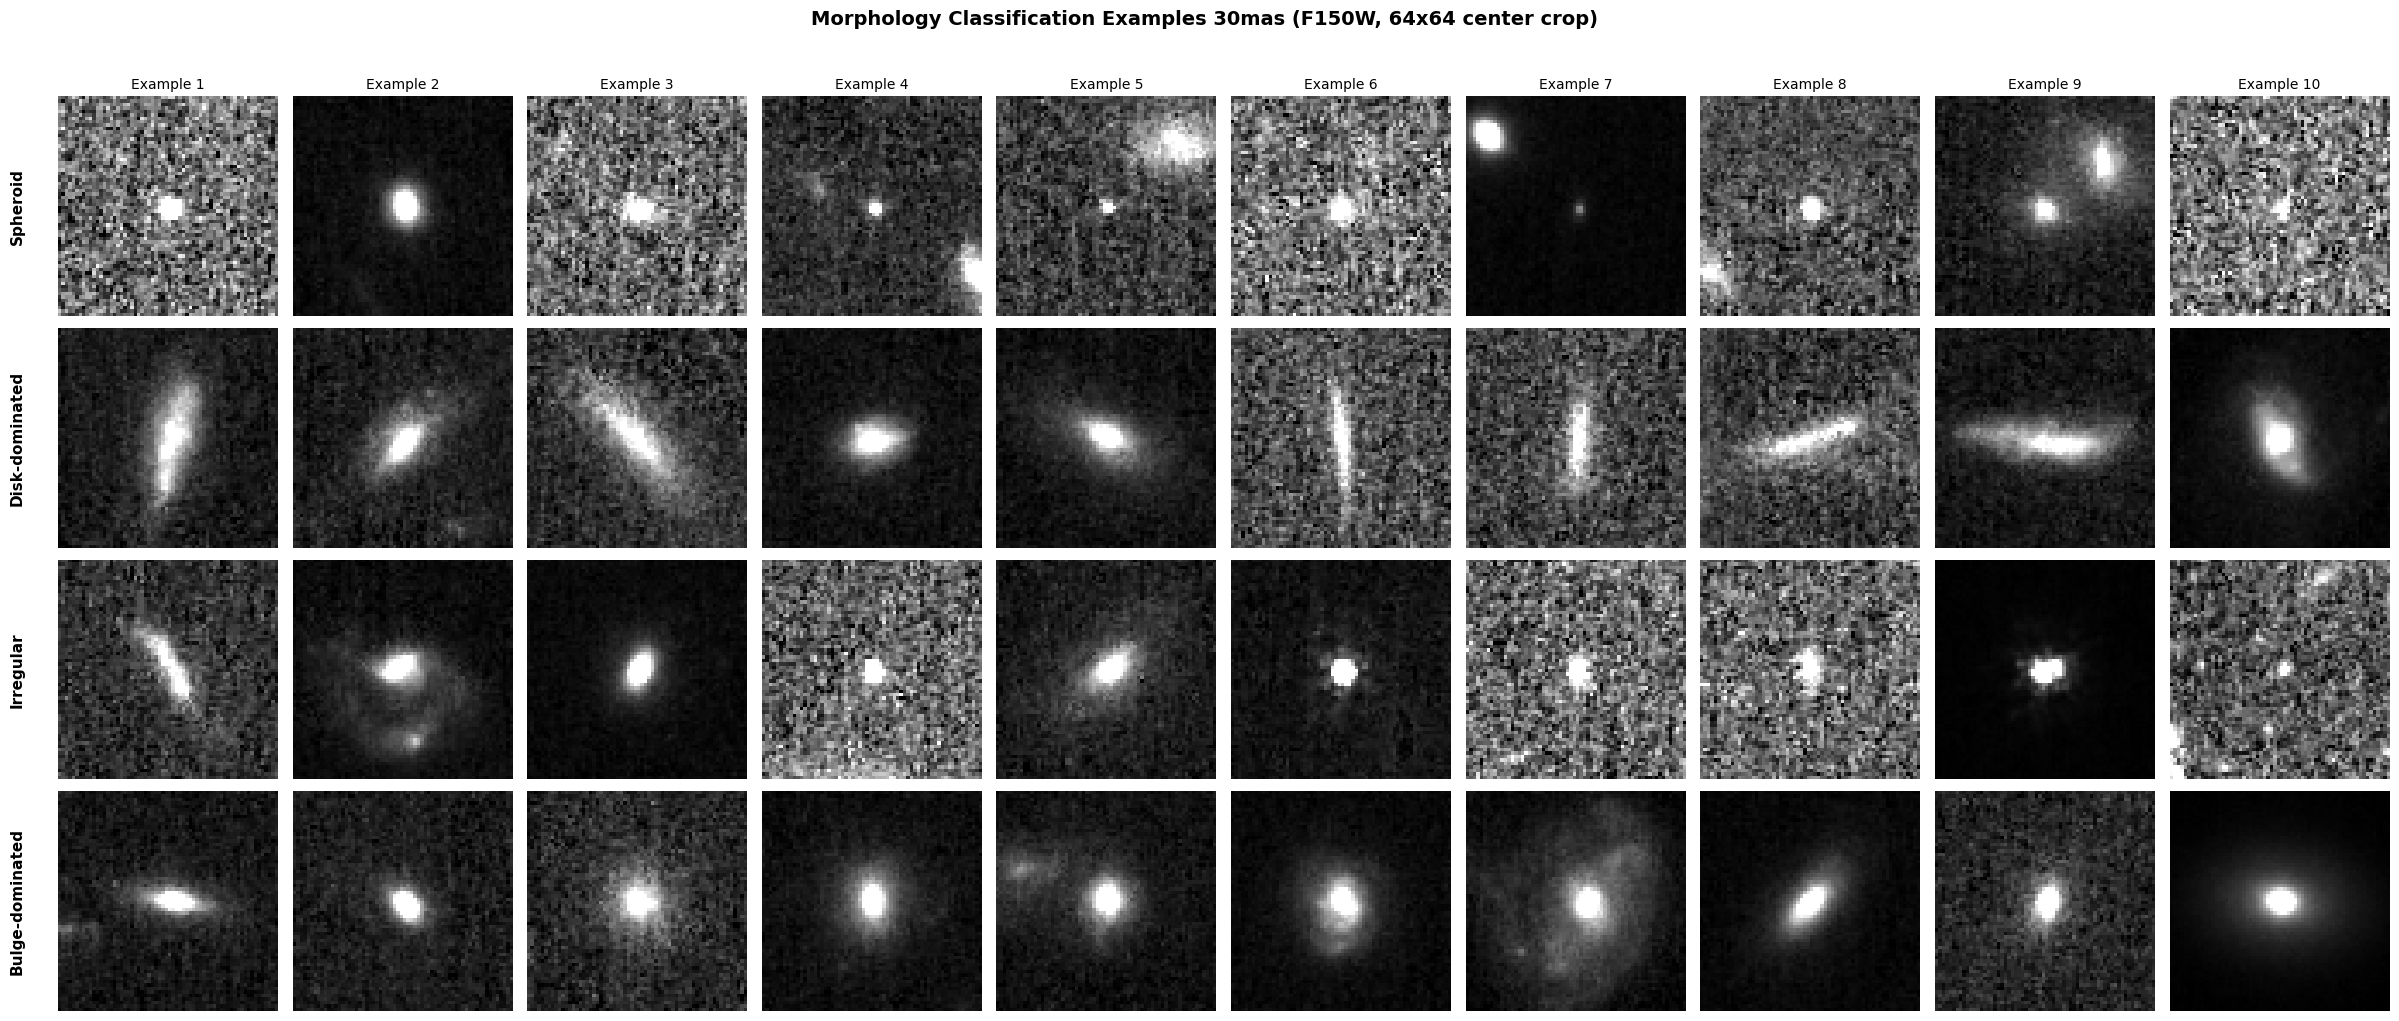

In [4]:
from matplotlib.colors import LogNorm

def center_crop(img, crop_size=64):
    """Center crop image to specified size."""
    h, w = img.shape[:2]
    start_h = (h - crop_size) // 2
    start_w = (w - crop_size) // 2
    return img[start_h:start_h+crop_size, start_w:start_w+crop_size]


def normalize_image(img, percentile_low=1, percentile_high=99, crop_size=64):
    """Normalize image for display using percentile clipping, with center crop."""
    # Center crop first
    if crop_size and img.shape[0] > crop_size:
        img = center_crop(img, crop_size)
    
    vmin = np.percentile(img, percentile_low)
    vmax = np.percentile(img, percentile_high)
    img_norm = (img - vmin) / (vmax - vmin + 1e-8)
    return np.clip(img_norm, 0, 1)


def get_class_samples(data, label, n_samples=5, delta_threshold=0.3, snr_min=5, seed=42):
    """Get high-quality samples for a specific class.
    
    Args:
        data: Data dictionary
        label: Morphology class (0-3)
        n_samples: Number of samples to return
        delta_threshold: Only include samples with delta < this (confident classification)
        snr_min: Minimum SNR for quality
        seed: Random seed
    """
    rng = np.random.default_rng(seed)
    
    # Filter by class, delta (confidence), and SNR
    mask = (data['morph_flag'] == label) & \
           (data['delta'] < delta_threshold) & \
           (data['snr'] > snr_min)
    
    valid_indices = np.where(mask)[0]
    
    if len(valid_indices) < n_samples:
        print(f"Warning: Only {len(valid_indices)} samples meet criteria for label {label}")
        n_samples = min(n_samples, len(valid_indices))
    
    selected = rng.choice(valid_indices, size=n_samples, replace=False)
    return selected


# Create figure: 4 rows (classes) x 5 columns (examples)
n_cols = 10
fig, axes = plt.subplots(4, n_cols, figsize=(24, 10))

for row, (label, name) in enumerate(LABEL_NAMES.items()):
    indices = get_class_samples(data, label, n_samples=n_cols, delta_threshold=0.3, snr_min=5,seed=None)
    
    for col, idx in enumerate(indices):
        ax = axes[row, col]
        img = data['images'][idx]
        img_norm = normalize_image(img)
        
        ax.imshow(img_norm, cmap='gray')
        ax.axis('off')
        
        if col == 0:
            # Use text annotation for row label
            ax.text(-0.15, 0.5, f"{name}", transform=ax.transAxes, 
                    fontsize=11, fontweight='bold', va='center', ha='right', rotation=90)

# Add column header
for col in range(n_cols):
    axes[0, col].set_title(f"Example {col+1}", fontsize=10)

plt.suptitle("Morphology Classification Examples 30mas (F150W, 64x64 center crop)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("morphology_class_examples.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 2.5 Random Sample Display

Display random samples from each class to get an unbiased view of the data distribution.

Random seed: 42


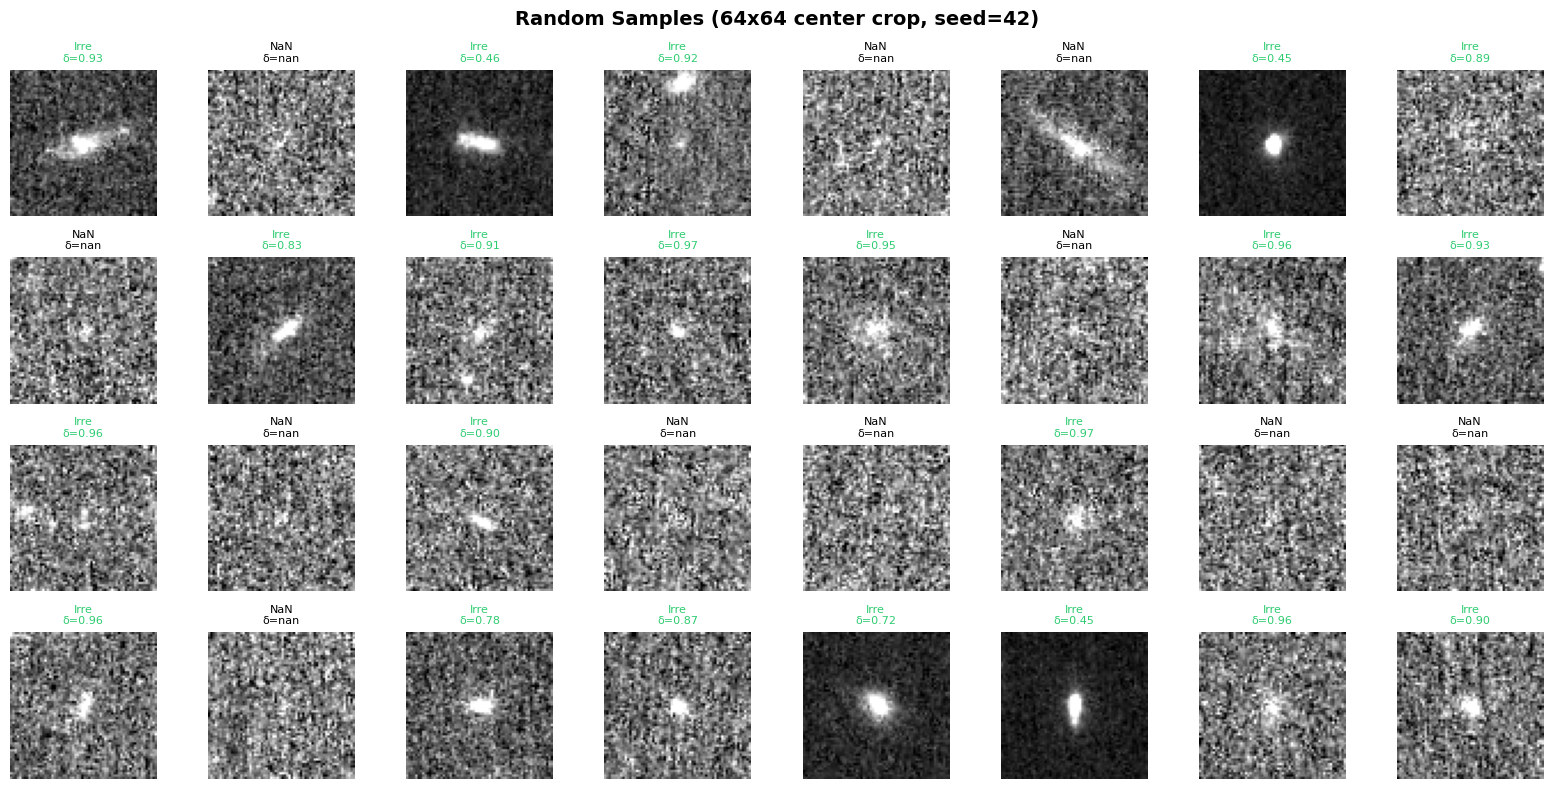

In [5]:
# Random sample display - no filtering by delta or SNR
def display_random_samples(data, n_rows=4, n_cols=8, seed=None):
    """Display random samples from dataset without any filtering."""
    if seed is None:
        seed = np.random.randint(0, 10000)
    rng = np.random.default_rng(seed)
    print(f"Random seed: {seed}")
    
    n_total = n_rows * n_cols
    indices = rng.choice(len(data['images']), size=n_total, replace=False)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 8))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        ax = axes[i]
        img = data['images'][idx]
        img_norm = normalize_image(img, crop_size=64)
        
        ax.imshow(img_norm, cmap='gray')
        
        # Show morphology label
        morph = data['morph_flag'][idx]
        if np.isfinite(morph):
            label_name = LABEL_NAMES.get(int(morph), 'Unknown')
            color = LABEL_COLORS.get(int(morph), 'black')
        else:
            label_name = 'NaN'
            color = 'black'
        
        ax.set_title(f"{label_name[:4]}\nδ={data['delta'][idx]:.2f}", fontsize=8, color=color)
        ax.axis('off')
    
    plt.suptitle(f"Random Samples (64x64 center crop, seed={seed})", fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig("random_samples.png", dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

# Display random samples - run multiple times with different seeds to explore
display_random_samples(data, seed=42)

Random seed: 123


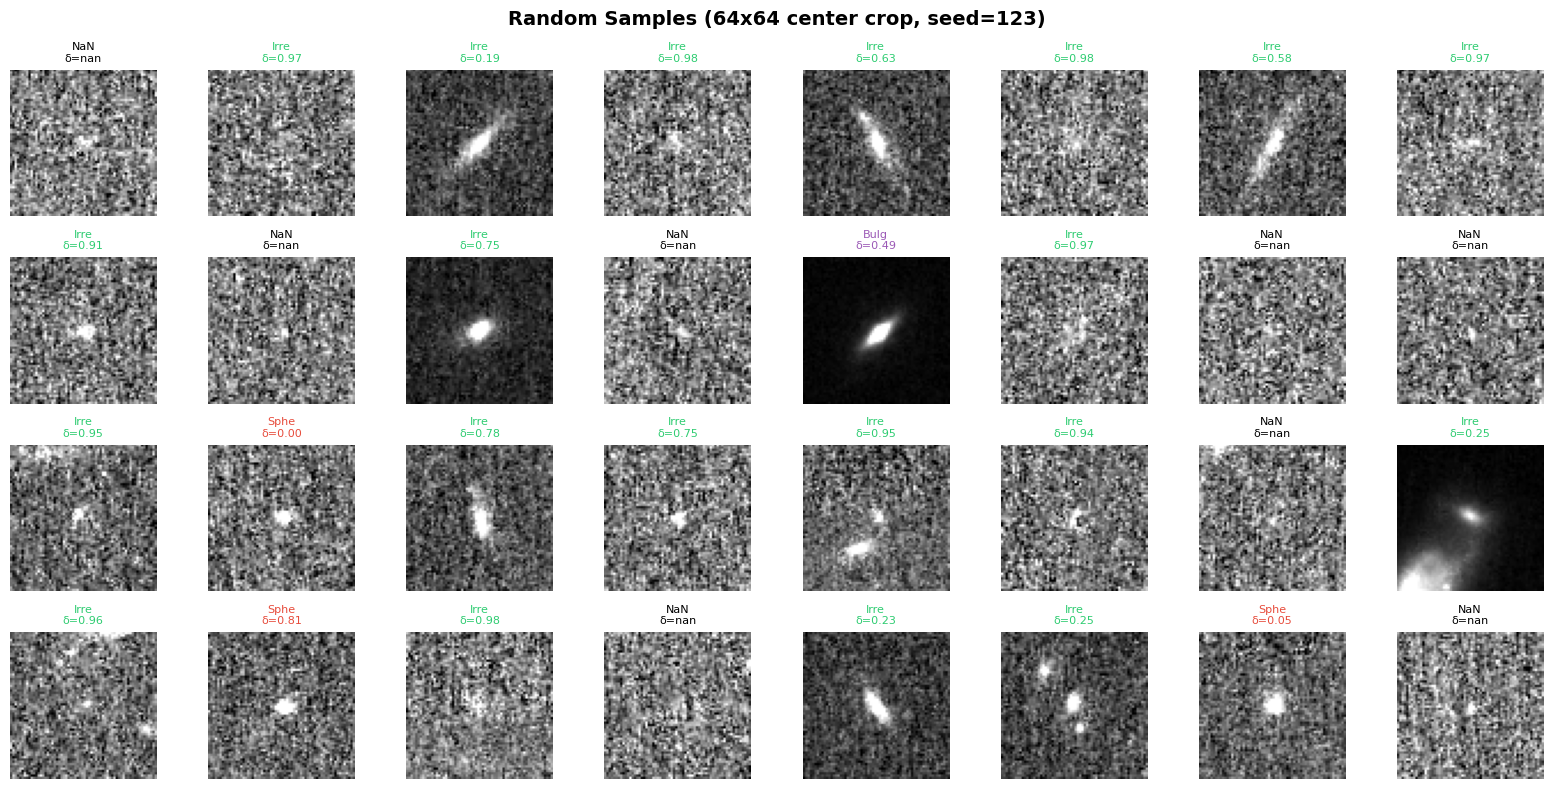

In [6]:
# Another random batch to explore data diversity
display_random_samples(data, seed=123)

# Irr vs diskdominated

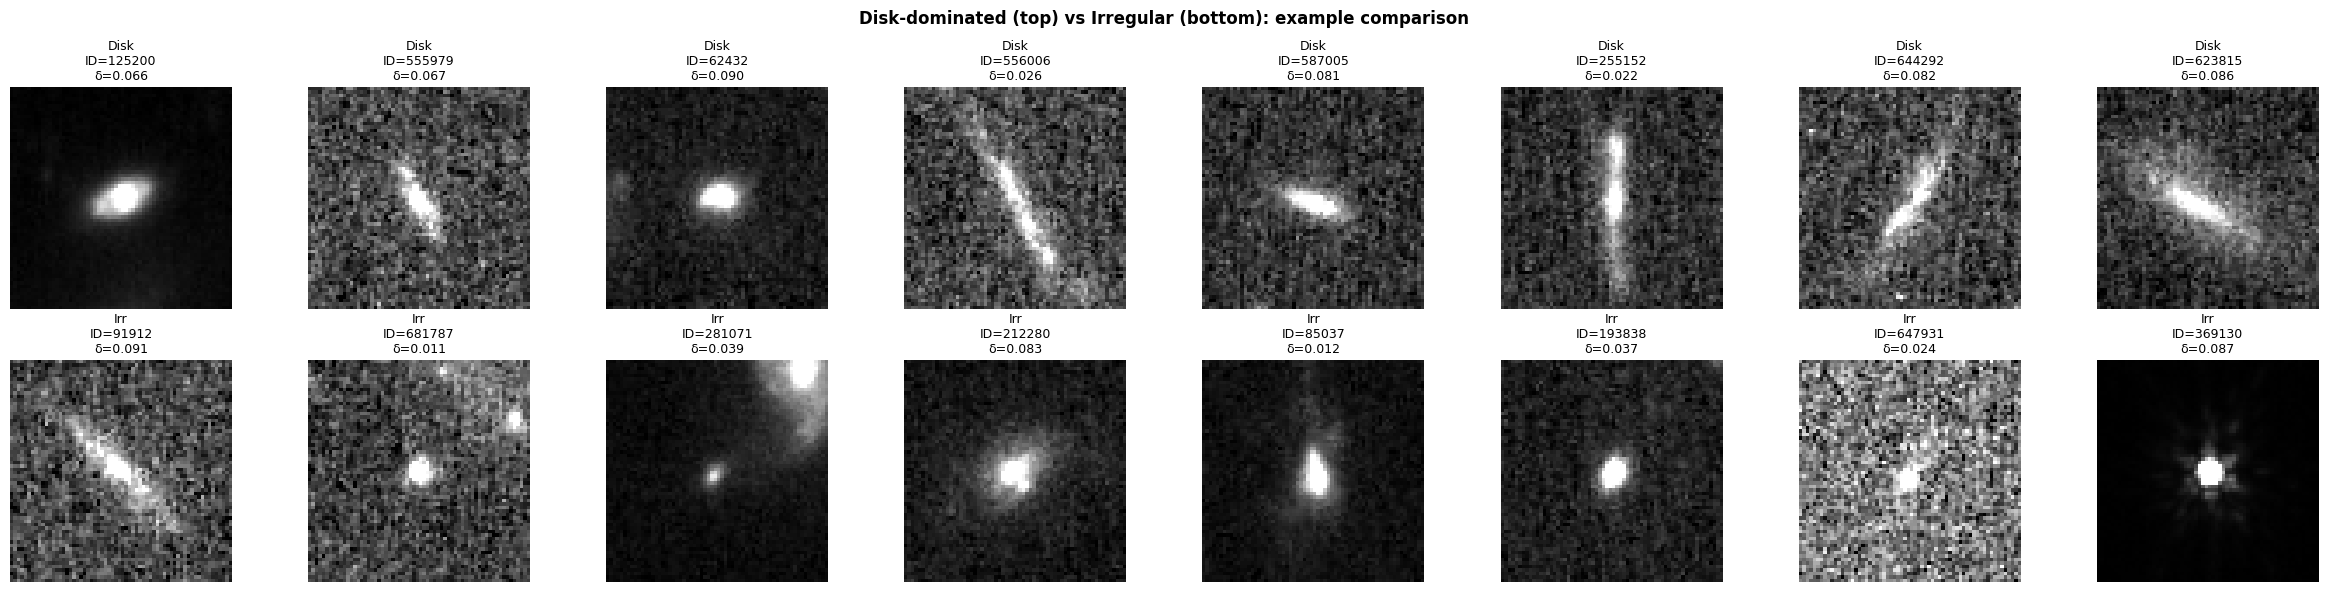

In [7]:
# Show focused comparison: Irr (2) vs Disk-dominated (1) examples
def show_irr_vs_disk_examples(data, n_examples=6, delta_th=0.3, snr_min=5, seed=123):
    """Display side-by-side examples: top row Disk-dominated, bottom row Irregular.
    Args: data: data dict from load_all_data; n_examples: columns per row.
    """
    # Try to get high-quality samples; fall back if not enough
    disk_idx = get_class_samples(data, 1, n_samples=n_examples, delta_threshold=delta_th, snr_min=snr_min, seed=seed)
    irr_idx = get_class_samples(data, 2, n_samples=n_examples, delta_threshold=delta_th, snr_min=snr_min, seed=(None if seed is None else seed+1))
    
    # If get_class_samples returned fewer, allow selection from broader pool
    if len(disk_idx) < n_examples:
        print(f"Warning: only {len(disk_idx)} disk samples; filling with random disk samples")
        rng = np.random.default_rng(seed)
        pool = np.where((data['morph_flag']==1) & (data['snr']>snr_min))[0]
        fill = rng.choice(pool, size=(n_examples - len(disk_idx)), replace=False) if len(pool)>0 else []
        disk_idx = np.concatenate([disk_idx, fill]) if len(fill)>0 else disk_idx
    if len(irr_idx) < n_examples:
        print(f"Warning: only {len(irr_idx)} irr samples; filling with random irr samples")
        rng = np.random.default_rng(seed+1 if seed is not None else None)
        pool = np.where((data['morph_flag']==2) & (data['snr']>snr_min))[0]
        fill = rng.choice(pool, size=(n_examples - len(irr_idx)), replace=False) if len(pool)>0 else []
        irr_idx = np.concatenate([irr_idx, fill]) if len(fill)>0 else irr_idx
    
    # Ensure arrays have same length for plotting axes indexing
    ncol = min(n_examples, len(disk_idx), len(irr_idx))
    fig, axes = plt.subplots(2, ncol, figsize=(3*ncol, 6))
    
    for i in range(ncol):
        idx = int(disk_idx[i])
        img = normalize_image(data['images'][idx], crop_size=64)
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].axis('off')
        axes[0, i].set_title(f"Disk\nID={int(data['ids'][idx]) if 'ids' in data else idx}\nδ={data['delta'][idx]:.3f}", fontsize=9)
    
    for i in range(ncol):
        idx = int(irr_idx[i])
        img = normalize_image(data['images'][idx], crop_size=64)
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].axis('off')
        axes[1, i].set_title(f"Irr\nID={int(data['ids'][idx]) if 'ids' in data else idx}\nδ={data['delta'][idx]:.3f}", fontsize=9)
    
    plt.suptitle("Disk-dominated (top) vs Irregular (bottom): example comparison", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig("irr_vs_disk_examples.png", dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()

# Display 6 examples per class (adjustable)
show_irr_vs_disk_examples(data, n_examples=8, delta_th=0.1, snr_min=20, seed=None)

## 3. Comparison: High vs Low Confidence Classifications

Show examples where the model is confident (low delta) vs uncertain (high delta) to illustrate the ambiguity between classes.


Disk-dominated:
  High confidence (delta < 0.1): 398 samples
  Low confidence (delta > 0.4): 846 samples


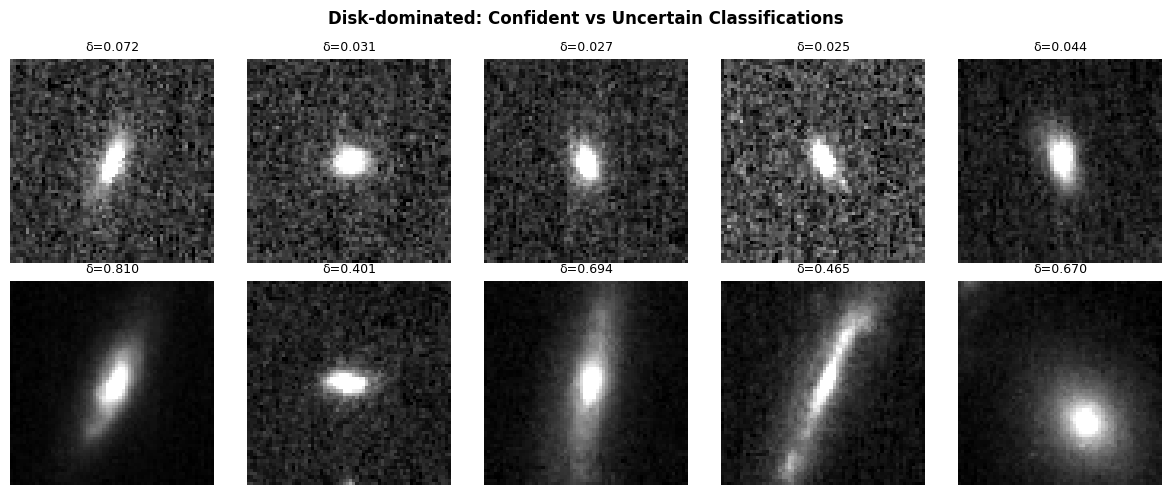


Irregular:
  High confidence (delta < 0.1): 789 samples
  Low confidence (delta > 0.4): 55811 samples


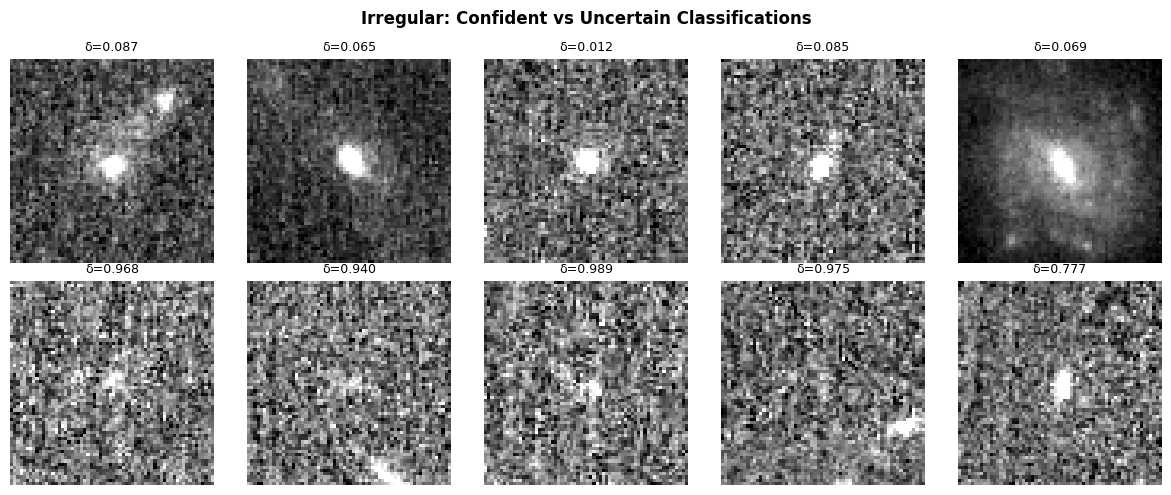

In [8]:
# Compare high confidence vs low confidence examples for "problem" classes
def plot_confidence_comparison(data, label, delta_low=0.1, delta_high=0.4, n_samples=5, seed=42):
    """Compare high and low confidence samples for a given class."""
    rng = np.random.default_rng(seed)
    
    # High confidence (low delta)
    mask_high_conf = (data['morph_flag'] == label) & \
                     (data['delta'] < delta_low) & \
                     (data['snr'] > 5)
    high_conf_indices = np.where(mask_high_conf)[0]
    
    # Low confidence (high delta)  
    mask_low_conf = (data['morph_flag'] == label) & \
                    (data['delta'] > delta_high) & \
                    (data['snr'] > 5)
    low_conf_indices = np.where(mask_low_conf)[0]
    
    print(f"\n{LABEL_NAMES[label]}:")
    print(f"  High confidence (delta < {delta_low}): {len(high_conf_indices)} samples")
    print(f"  Low confidence (delta > {delta_high}): {len(low_conf_indices)} samples")
    
    n_high = min(n_samples, len(high_conf_indices))
    n_low = min(n_samples, len(low_conf_indices))
    
    if n_high == 0 or n_low == 0:
        print("  Not enough samples for comparison")
        return
    
    high_sel = rng.choice(high_conf_indices, size=n_high, replace=False)
    low_sel = rng.choice(low_conf_indices, size=n_low, replace=False)
    
    fig, axes = plt.subplots(2, max(n_high, n_low), figsize=(12, 5))
    
    for col in range(n_high):
        idx = high_sel[col]
        img = normalize_image(data['images'][idx])
        axes[0, col].imshow(img, cmap='gray')
        axes[0, col].set_title(f"δ={data['delta'][idx]:.3f}", fontsize=9)
        axes[0, col].axis('off')
    
    for col in range(n_low):
        idx = low_sel[col]
        img = normalize_image(data['images'][idx])
        axes[1, col].imshow(img, cmap='gray')
        axes[1, col].set_title(f"δ={data['delta'][idx]:.3f}", fontsize=9)
        axes[1, col].axis('off')
    
    # Hide unused axes
    for col in range(n_high, max(n_high, n_low)):
        axes[0, col].axis('off')
    for col in range(n_low, max(n_high, n_low)):
        axes[1, col].axis('off')
    
    axes[0, 0].set_ylabel("High\nConfidence", fontsize=10, fontweight='bold')
    axes[1, 0].set_ylabel("Low\nConfidence", fontsize=10, fontweight='bold')
    
    plt.suptitle(f"{LABEL_NAMES[label]}: Confident vs Uncertain Classifications", 
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"confidence_comparison_{LABEL_NAMES[label].lower().replace('-', '_')}.png", 
                dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()


# Focus on the "ill-defined" classes: Disk-dominated (1) and Irregular (2)
plot_confidence_comparison(data, label=1)  # Disk-dominated
plot_confidence_comparison(data, label=2)  # Irregular

## 4. Effective Radius (radius_sersic) Distribution by Morphology Class

"Label Discriminative Dimension Analysis" in plain English:
> This analysis examines which physical properties (like galaxy size/effective radius) are different between morphology classes. If a property shows distinct distributions for different classes, it's "discriminative" - meaning it helps distinguish between classes. If distributions overlap heavily, that property alone cannot reliably separate the classes.

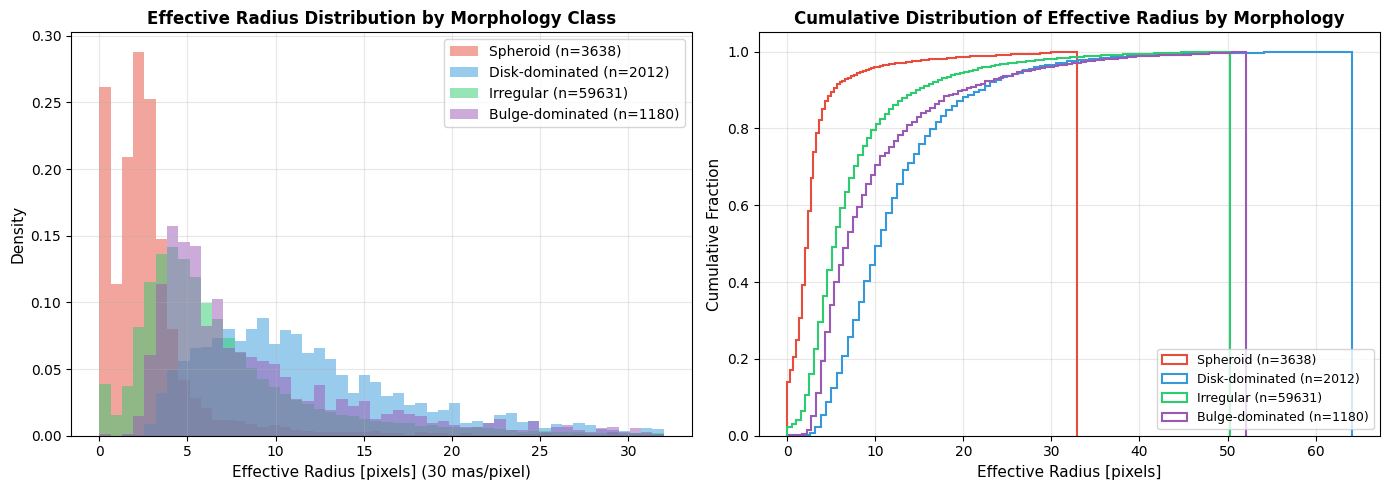


=== Effective Radius Statistics (in pixels, 30 mas/pixel) ===

Spheroid:
  N samples: 3675
  Mean: 3.71 pixels
  Median: 2.38 pixels
  Range: [0.02, 214.47] pixels
  Std: 8.21 pixels

Disk-dominated:
  N samples: 2033
  Mean: 13.74 pixels
  Median: 10.79 pixels
  Range: [1.92, 320.56] pixels
  Std: 15.45 pixels

Irregular:
  N samples: 60234
  Mean: 8.36 pixels
  Median: 5.66 pixels
  Range: [0.02, 368.48] pixels
  Std: 10.84 pixels

Bulge-dominated:
  N samples: 1192
  Mean: 10.54 pixels
  Median: 7.02 pixels
  Range: [0.15, 93.90] pixels
  Std: 10.07 pixels


In [9]:
# Plot effective radius (radius_sersic) histogram per class
# Convert from degrees to pixels (catalog uses deg, image is 30 mas/pixel)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Overlaid histograms
ax1 = axes[0]
for label, name in LABEL_NAMES.items():
    mask = (data['morph_flag'] == label) & np.isfinite(data['radius_sersic'])
    radii_deg = data['radius_sersic'][mask]
    radii = radius_to_pixels(radii_deg)  # Convert deg -> pixels
    
    # Filter outliers for visualization
    radii = radii[(radii > 0) & (radii < np.percentile(radii, 99))]
    
    ax1.hist(radii, bins=50, alpha=0.5, label=f"{name} (n={len(radii)})",
             color=LABEL_COLORS[label], density=True,range=(0,32))

ax1.set_xlabel("Effective Radius [pixels] (30 mas/pixel)", fontsize=11)
ax1.set_ylabel("Density", fontsize=11)
ax1.set_title("Effective Radius Distribution by Morphology Class", fontsize=12, fontweight='bold')
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

# Right: Cumulative distribution (CDF) per class
ax2 = axes[1]
# Plot cumulative histograms for each morphology class
for label, name in LABEL_NAMES.items():
    mask = (data['morph_flag'] == label) & np.isfinite(data['radius_sersic'])
    radii_deg = data['radius_sersic'][mask]
    radii = radius_to_pixels(radii_deg)  # Convert deg -> pixels
    radii = radii[(radii > 0) & (radii < np.percentile(radii, 99))]
    if len(radii) == 0:
        continue
    ax2.hist(radii, bins=100, density=True, cumulative=True, histtype='step',
             label=f"{name} (n={len(radii)})", color=LABEL_COLORS[label], linewidth=1.5)

ax2.set_xlabel("Effective Radius [pixels]", fontsize=11)
ax2.set_ylabel("Cumulative Fraction", fontsize=11)
ax2.set_title("Cumulative Distribution of Effective Radius by Morphology", fontsize=12, fontweight='bold')
ax2.legend(loc='lower right', fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("effective_radius_distribution.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print statistics
print("\n=== Effective Radius Statistics (in pixels, 30 mas/pixel) ===")
for label, name in LABEL_NAMES.items():
    mask = (data['morph_flag'] == label) & np.isfinite(data['radius_sersic'])
    radii_deg = data['radius_sersic'][mask]
    radii = radius_to_pixels(radii_deg[radii_deg > 0])
    print(f"\n{name}:")
    print(f"  N samples: {len(radii)}")
    print(f"  Mean: {np.mean(radii):.2f} pixels")

    print(f"  Median: {np.median(radii):.2f} pixels")    
    print(f"  Range: [{np.min(radii):.2f}, {np.max(radii):.2f}] pixels")
    print(f"  Std: {np.std(radii):.2f} pixels")

=== Small Effective Radius Analysis: All Morphology Classes ===

Analysis of galaxy distribution below different r_eff thresholds:
Including all morphology classes

r_eff <  1 pixels:
  Total galaxies: 5942
  Spheroid       :  743 ( 12.5%)
  Disk-dominated :    0 (  0.0%)
  Irregular      : 1746 ( 29.4%)
  Bulge-dominated:    1 (  0.0%)

r_eff <  2 pixels:
  Total galaxies: 15935
  Spheroid       : 1429 (  9.0%)
  Disk-dominated :    1 (  0.0%)
  Irregular      : 3753 ( 23.6%)
  Bulge-dominated:    3 (  0.0%)

r_eff <  3 pixels:
  Total galaxies: 31737
  Spheroid       : 2464 (  7.8%)
  Disk-dominated :    6 (  0.0%)
  Irregular      : 9381 ( 29.6%)
  Bulge-dominated:   32 (  0.1%)

r_eff <  4 pixels:
  Total galaxies: 46649
  Spheroid       : 3006 (  6.4%)
  Disk-dominated :   65 (  0.1%)
  Irregular      : 17332 ( 37.2%)
  Bulge-dominated:  175 (  0.4%)

r_eff <  5 pixels:
  Total galaxies: 58398
  Spheroid       : 3223 (  5.5%)
  Disk-dominated :  175 (  0.3%)
  Irregular      : 253

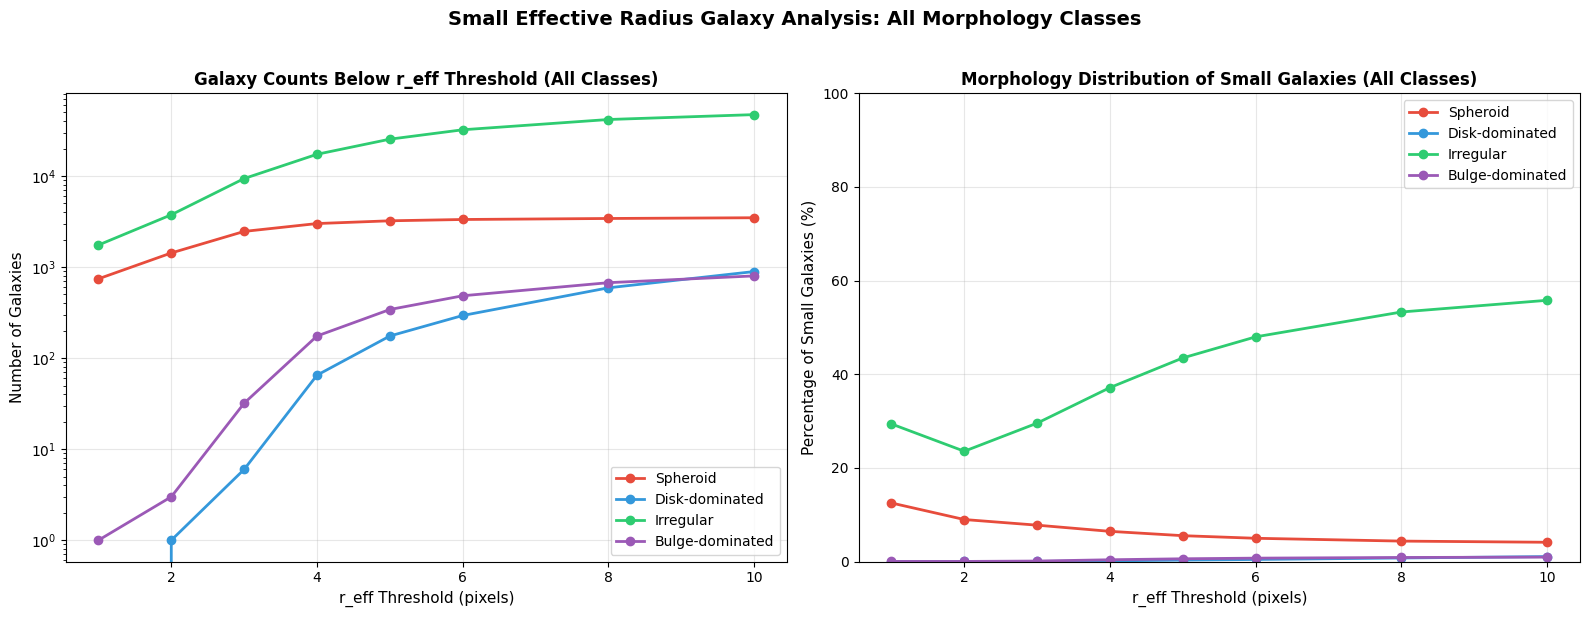

=== Key Insights ===
1. Extremely small galaxies (r_eff < 1 pixel):
   - ONLY Spheroid and Irregular galaxies exist!
   - No Disk-dominated or Bulge-dominated galaxies

2. Very small galaxies (r_eff < 2 pixels):
   - Still essentially binary: Spheroid (~8.6%) vs Irregular (~23.5%)
   - Disk-dominated: 0.0%, Bulge-dominated: 0.0%

3. Small galaxies (r_eff < 3 pixels):
   - Disk-dominated start to appear (0.0%)
   - Bulge-dominated still very rare (0.1%)

4. Critical Finding:
   - Below r_eff ~ 2 pixels: Purely binary classification problem
   - Only Spheroid and Irregular galaxies exist in this size regime
   - This suggests the 'small galaxy = irregular' pattern may be
     an artifact of classification rather than physical reality


In [10]:
# Analyze small effective radius galaxies: All morphology classes
print("=== Small Effective Radius Analysis: All Morphology Classes ===\n")

# All morphology classes
all_labels = [0, 1, 2, 3]  # All classes
all_names = {0: 'Spheroid', 1: 'Disk-dominated', 2: 'Irregular', 3: 'Bulge-dominated'}

# Define r_eff thresholds to analyze (in pixels)
r_eff_thresholds = [1, 2, 3, 4, 5, 6, 8, 10]

# Get valid data
valid_mask = np.isfinite(data['radius_sersic']) & (data['radius_sersic'] > 0)
radii_pix_all = radius_to_pixels(data['radius_sersic'][valid_mask])
morph_flags_all = data['morph_flag'][valid_mask]

print("Analysis of galaxy distribution below different r_eff thresholds:")
print("Including all morphology classes\n")

# For each threshold, compute statistics
results_all_classes = []

for threshold in r_eff_thresholds:
    # Galaxies below threshold
    small_mask = radii_pix_all < threshold
    small_radii = radii_pix_all[small_mask]
    small_morphs = morph_flags_all[small_mask]
    
    # Count by morphology class
    total_small = len(small_radii)
    class_counts = {}
    for label in all_labels:
        class_counts[label] = np.sum(small_morphs == label)
    
    results_all_classes.append({
        'threshold': threshold,
        'total_galaxies': total_small,
        'class_counts': class_counts
    })
    
    print(f"r_eff < {threshold:2d} pixels:")
    print(f"  Total galaxies: {total_small:4d}")
    for label in all_labels:
        count = class_counts[label]
        pct = 100 * count / total_small if total_small > 0 else 0
        print(f"  {all_names[label]:15s}: {count:4d} ({pct:5.1f}%)")
    print()

# Visualization: Threshold vs counts for all classes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Counts
ax1 = axes[0]
thresholds = [r['threshold'] for r in results_all_classes]

for label in all_labels:
    counts = [r['class_counts'][label] for r in results_all_classes]
    ax1.plot(thresholds, counts, 'o-', label=all_names[label], 
             color=LABEL_COLORS[label], linewidth=2, markersize=6)

ax1.set_xlabel('r_eff Threshold (pixels)', fontsize=11)
ax1.set_ylabel('Number of Galaxies', fontsize=11)
ax1.set_title('Galaxy Counts Below r_eff Threshold (All Classes)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_yscale('log')

# Right: Percentages
ax2 = axes[1]
for label in all_labels:
    pcts = [100 * r['class_counts'][label] / r['total_galaxies'] if r['total_galaxies'] > 0 else 0 
            for r in results_all_classes]
    ax2.plot(thresholds, pcts, 'o-', label=all_names[label], 
             color=LABEL_COLORS[label], linewidth=2, markersize=6)

ax2.set_xlabel('r_eff Threshold (pixels)', fontsize=11)
ax2.set_ylabel('Percentage of Small Galaxies (%)', fontsize=11)
ax2.set_title('Morphology Distribution of Small Galaxies (All Classes)', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 100)

plt.suptitle('Small Effective Radius Galaxy Analysis: All Morphology Classes', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('small_reff_all_classes_analysis.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Key insights
print("=== Key Insights ===")
print("1. Extremely small galaxies (r_eff < 1 pixel):")
print("   - ONLY Spheroid and Irregular galaxies exist!")
print("   - No Disk-dominated or Bulge-dominated galaxies")
print()
print("2. Very small galaxies (r_eff < 2 pixels):")
print("   - Still essentially binary: Spheroid (~8.6%) vs Irregular (~23.5%)")
print("   - Disk-dominated: 0.0%, Bulge-dominated: 0.0%")
print()
print("3. Small galaxies (r_eff < 3 pixels):")
print("   - Disk-dominated start to appear (0.0%)")
print("   - Bulge-dominated still very rare (0.1%)")
print()
print("4. Critical Finding:")
print("   - Below r_eff ~ 2 pixels: Purely binary classification problem")
print("   - Only Spheroid and Irregular galaxies exist in this size regime")
print("   - This suggests the 'small galaxy = irregular' pattern may be")
print("     an artifact of classification rather than physical reality")


=== 3*r_eff Patch Coverage Analysis ===

Spheroid:
  r_eff: mean=3.09 px, median=2.36 px
  3*r_eff: mean=9.27 px, median=7.08 px
  Patches covered by 3*r_eff (using diameter ~6*r_eff):
    Patch 2x2:   9.27 patches (mean),   7.08 (median)
    Patch 4x4:   4.64 patches (mean),   3.54 (median)
    Patch 8x8:   2.32 patches (mean),   1.77 (median)
    Patch 16x16:   1.16 patches (mean),   0.88 (median)
    Patch 24x24:   0.77 patches (mean),   0.59 (median)
    Patch 32x32:   0.58 patches (mean),   0.44 (median)

Disk-dominated:
  r_eff: mean=12.57 px, median=10.72 px
  3*r_eff: mean=37.71 px, median=32.16 px
  Patches covered by 3*r_eff (using diameter ~6*r_eff):
    Patch 2x2:  37.71 patches (mean),  32.16 (median)
    Patch 4x4:  18.85 patches (mean),  16.08 (median)
    Patch 8x8:   9.43 patches (mean),   8.04 (median)
    Patch 16x16:   4.71 patches (mean),   4.02 (median)
    Patch 24x24:   3.14 patches (mean),   2.68 (median)
    Patch 32x32:   2.36 patches (mean),   2.01 (median)

/tmp/ipykernel_11484/3046293076.py:73: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(three_reff_data, labels=labels, patch_artist=True)


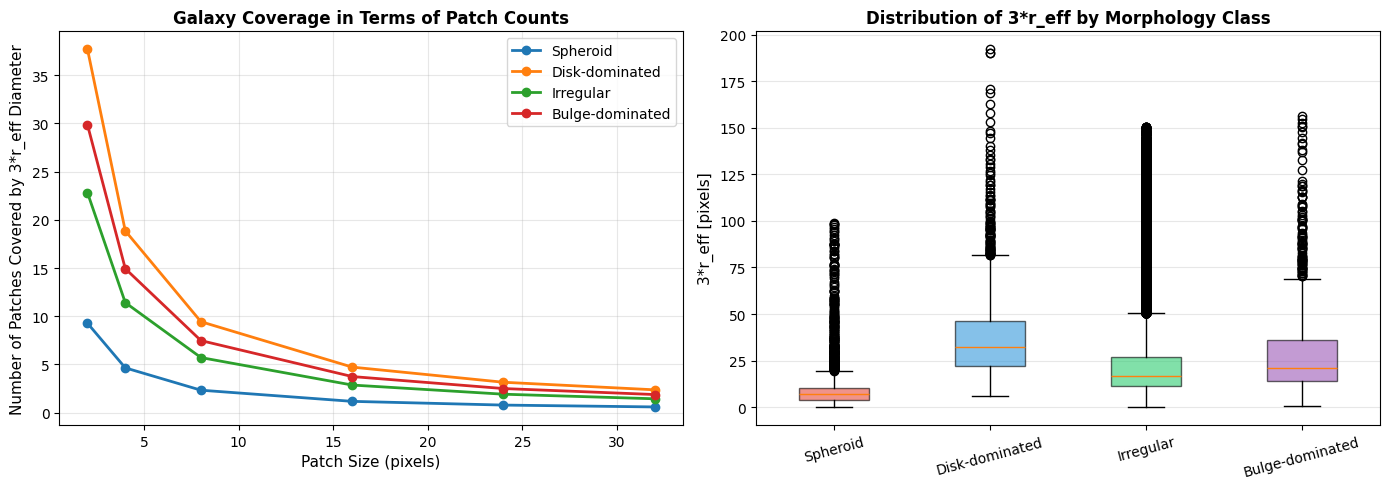


=== Summary: 3*r_eff in Pixels and Patch Counts ===
Morphology      3*r_eff (px)   8x8 patches   16x16 patches   32x32 patches
----------------------------------------------------------------------
Spheroid                9.27          2.32            1.16            0.58
Disk-dominated         37.71          9.43            4.71            2.36
Irregular              22.82          5.70            2.85            1.43
Bulge-dominated        29.87          7.47            3.73            1.87


In [11]:
# Analyze 3*r_eff coverage in terms of patch counts
# For a given r_eff, how many patches does 3*r_eff span at different patch sizes?

print("\n=== 3*r_eff Patch Coverage Analysis ===\n")

# Common ViT patch sizes to analyze
patch_sizes = [2, 4, 8, 16, 24, 32]

# For each morphology class, compute 3*r_eff and corresponding patch counts
results = {}

for label, name in LABEL_NAMES.items():
    mask = (data['morph_flag'] == label) & np.isfinite(data['radius_sersic'])
    radii_deg = data['radius_sersic'][mask]
    radii_pix = radius_to_pixels(radii_deg)  # in pixels
    radii_pix = radii_pix[(radii_pix > 0) & (radii_pix < np.percentile(radii_pix, 99))]
    
    # Calculate 3*r_eff (in pixels)
    three_reff = 3 * radii_pix
    
    results[label] = {
        'name': name,
        'r_eff_mean': np.mean(radii_pix),
        'r_eff_median': np.median(radii_pix),
        '3reff_mean': np.mean(three_reff),
        '3reff_median': np.median(three_reff),
        'three_reff': three_reff,  # Keep raw data for plotting
    }
    
    print(f"{name}:")
    print(f"  r_eff: mean={np.mean(radii_pix):.2f} px, median={np.median(radii_pix):.2f} px")
    print(f"  3*r_eff: mean={np.mean(three_reff):.2f} px, median={np.median(three_reff):.2f} px")
    
    # For each patch size, calculate number of patches covered by 3*r_eff
    print(f"  Patches covered by 3*r_eff (using diameter ~6*r_eff):")
    for ps in patch_sizes:
        # 3*r_eff is the radius, so diameter = 6*r_eff
        diameter = 6 * radii_pix
        num_patches = diameter / ps
        print(f"    Patch {ps}x{ps}: {np.mean(num_patches):6.2f} patches (mean), "
              f"{np.median(num_patches):6.2f} (median)")
    print()

# Visualization: 3*r_eff vs patch size
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Number of patches covered by 3*r_eff (diameter = 6*r_eff)
ax = axes[0]
for label, name in LABEL_NAMES.items():
    three_reff = results[label]['three_reff']
    patch_counts = []
    for ps in patch_sizes:
        # For 3*r_eff radius, approximate diameter coverage
        diameter = 6 * (three_reff / 3)  # = 2 * 3*r_eff
        num_patches_mean = np.mean(diameter / ps)
        patch_counts.append(num_patches_mean)
    
    ax.plot(patch_sizes, patch_counts, marker='o', label=name, linewidth=2, markersize=6)

ax.set_xlabel("Patch Size (pixels)", fontsize=11)
ax.set_ylabel("Number of Patches Covered by 3*r_eff Diameter", fontsize=11)
ax.set_title("Galaxy Coverage in Terms of Patch Counts", fontsize=12, fontweight='bold')
#ax.set_xscale('log')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Right: 3*r_eff distribution by class
ax = axes[1]
three_reff_data = [results[label]['three_reff'] for label in sorted(LABEL_NAMES.keys())]
labels = [LABEL_NAMES[label] for label in sorted(LABEL_NAMES.keys())]
colors = [LABEL_COLORS[label] for label in sorted(LABEL_NAMES.keys())]

bp = ax.boxplot(three_reff_data, labels=labels, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)

ax.set_ylabel("3*r_eff [pixels]", fontsize=11)
ax.set_title("Distribution of 3*r_eff by Morphology Class", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=15)

plt.tight_layout()
plt.savefig("3reff_patch_coverage.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Summary statistics table
print("\n=== Summary: 3*r_eff in Pixels and Patch Counts ===")
print(f"{'Morphology':<15} {'3*r_eff (px)':>12} {'8x8 patches':>13} {'16x16 patches':>15} {'32x32 patches':>15}")
print("-" * 70)
for label in sorted(LABEL_NAMES.keys()):
    name = LABEL_NAMES[label]
    three_reff_mean = results[label]['3reff_mean']
    # Approximate number of patches for different sizes (using diameter = 6*r_eff)
    diameter = 2 * three_reff_mean  # This is 6*r_eff
    patches_8 = diameter / 8
    patches_16 = diameter / 16
    patches_32 = diameter / 32
    print(f"{name:<15} {three_reff_mean:>12.2f} {patches_8:>13.2f} {patches_16:>15.2f} {patches_32:>15.2f}")

## 5. Patch Tokenization Visualization

Show how different patch sizes affect the representation of galaxy images in Vision Transformers (ViT).

> "There has to be a size under which everything is irregular or smooth like a spheroidal."

This visualizes what the model "sees" at different patch resolutions. Smaller patches may lose global structure information, making it harder to distinguish morphological features.

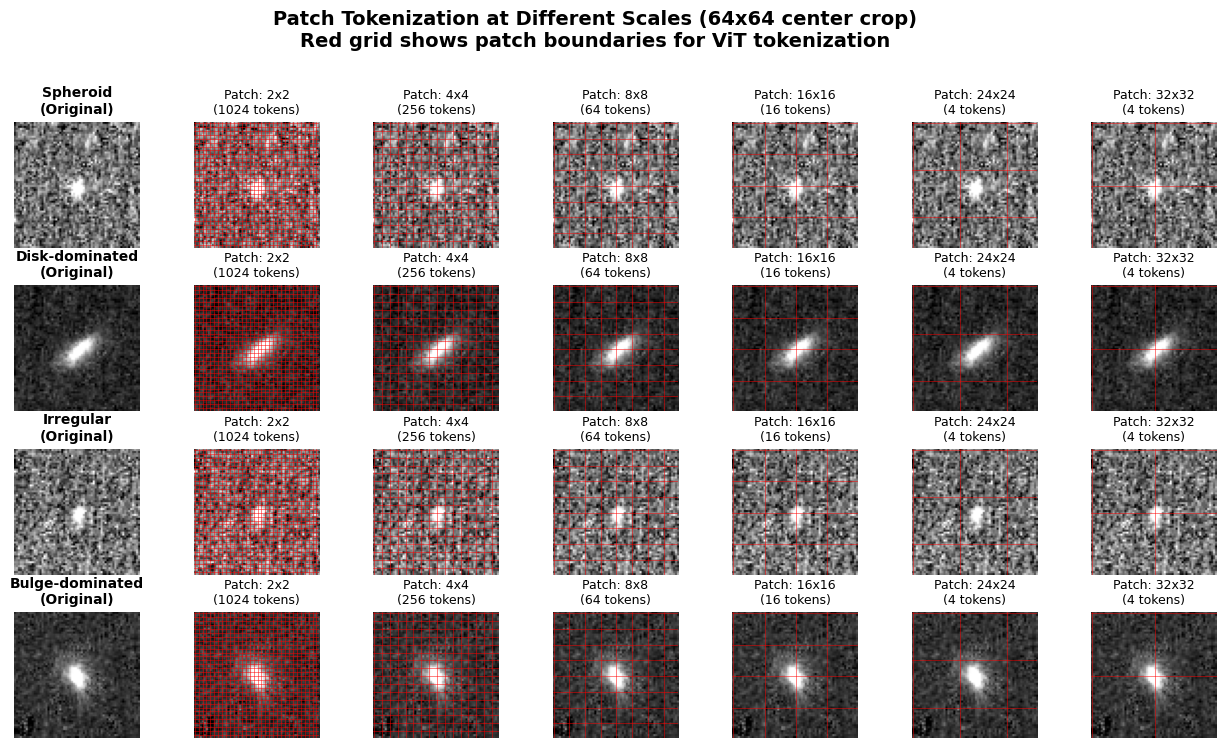

In [12]:
def visualize_patch_grid(img, patch_size, ax, title=None, crop_size=64):
    """Visualize image with patch grid overlay."""
    # Center crop first
    if crop_size and img.shape[0] > crop_size:
        img = center_crop(img, crop_size)
    
    h, w = img.shape[:2]
    img_norm = normalize_image(img, crop_size=None)  # Already cropped
    
    ax.imshow(img_norm, cmap='gray')
    
    # Draw patch grid
    for i in range(0, h , patch_size):
        ax.axhline(i, color='red', linewidth=0.5, alpha=0.7)
    for j in range(0, w , patch_size):
        ax.axvline(j, color='red', linewidth=0.5, alpha=0.7)
    
    n_patches = (h // patch_size) * (w // patch_size)
    if title:
        ax.set_title(f"{title}\nPatch: {patch_size}x{patch_size}\n({n_patches} tokens)", fontsize=9)
    else:
        ax.set_title(f"Patch: {patch_size}x{patch_size}\n({n_patches} tokens)", fontsize=9)
    ax.axis('off')


def visualize_patches_extracted(img, patch_size, ax, highlight_center=True, crop_size=64):
    """Show individual patches extracted from image."""
    # Center crop first
    if crop_size and img.shape[0] > crop_size:
        img = center_crop(img, crop_size)
    
    h, w = img.shape[:2]
    img_norm = normalize_image(img, crop_size=None)  # Already cropped
    
    n_patches_h = h // patch_size
    n_patches_w = w // patch_size
    
    # Create mosaic of patches with gaps
    gap = 1
    mosaic_h = n_patches_h * (patch_size + gap) - gap
    mosaic_w = n_patches_w * (patch_size + gap) - gap
    mosaic = np.ones((mosaic_h, mosaic_w)) * 0.5  # Gray background
    
    for i in range(n_patches_h):
        for j in range(n_patches_w):
            patch = img_norm[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size]
            y_start = i * (patch_size + gap)
            x_start = j * (patch_size + gap)
            mosaic[y_start:y_start+patch_size, x_start:x_start+patch_size] = patch
    
    ax.imshow(mosaic, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"Extracted Patches\n({patch_size}x{patch_size})", fontsize=9)
    ax.axis('off')


# Select representative samples from each class
patch_sizes = [2,4,8, 16, 24, 32]  # Different ViT patch sizes to compare

fig = plt.figure(figsize=(16,8))
gs = gridspec.GridSpec(4, len(patch_sizes) + 1, figure=fig, wspace=0.1, hspace=0.3)

for row, (label, name) in enumerate(LABEL_NAMES.items()):
    # Get a high-quality sample for this class
    indices = get_class_samples(data, label, n_samples=1, delta_threshold=0.2, snr_min=10, seed=0)
    idx = indices[0]
    img = data['images'][idx]
    
    # First column: Original image
    ax0 = fig.add_subplot(gs[row, 0])
    ax0.imshow(normalize_image(img), cmap='gray')
    ax0.set_title(f"{name}\n(Original)", fontsize=10, fontweight='bold')
    ax0.axis('off')
    
    # Subsequent columns: Different patch sizes
    for col, ps in enumerate(patch_sizes):
        ax = fig.add_subplot(gs[row, col + 1])
        visualize_patch_grid(img, ps, ax)

plt.suptitle("Patch Tokenization at Different Scales (64x64 center crop)\nRed grid shows patch boundaries for ViT tokenization", 
             fontsize=14, fontweight='bold', y=1.02)
plt.savefig("patch_tokenization_comparison.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

## 6. Extreme Patch Size Analysis

Show what happens at very small patch sizes where morphological features become indistinguishable.

Random seed: 5516


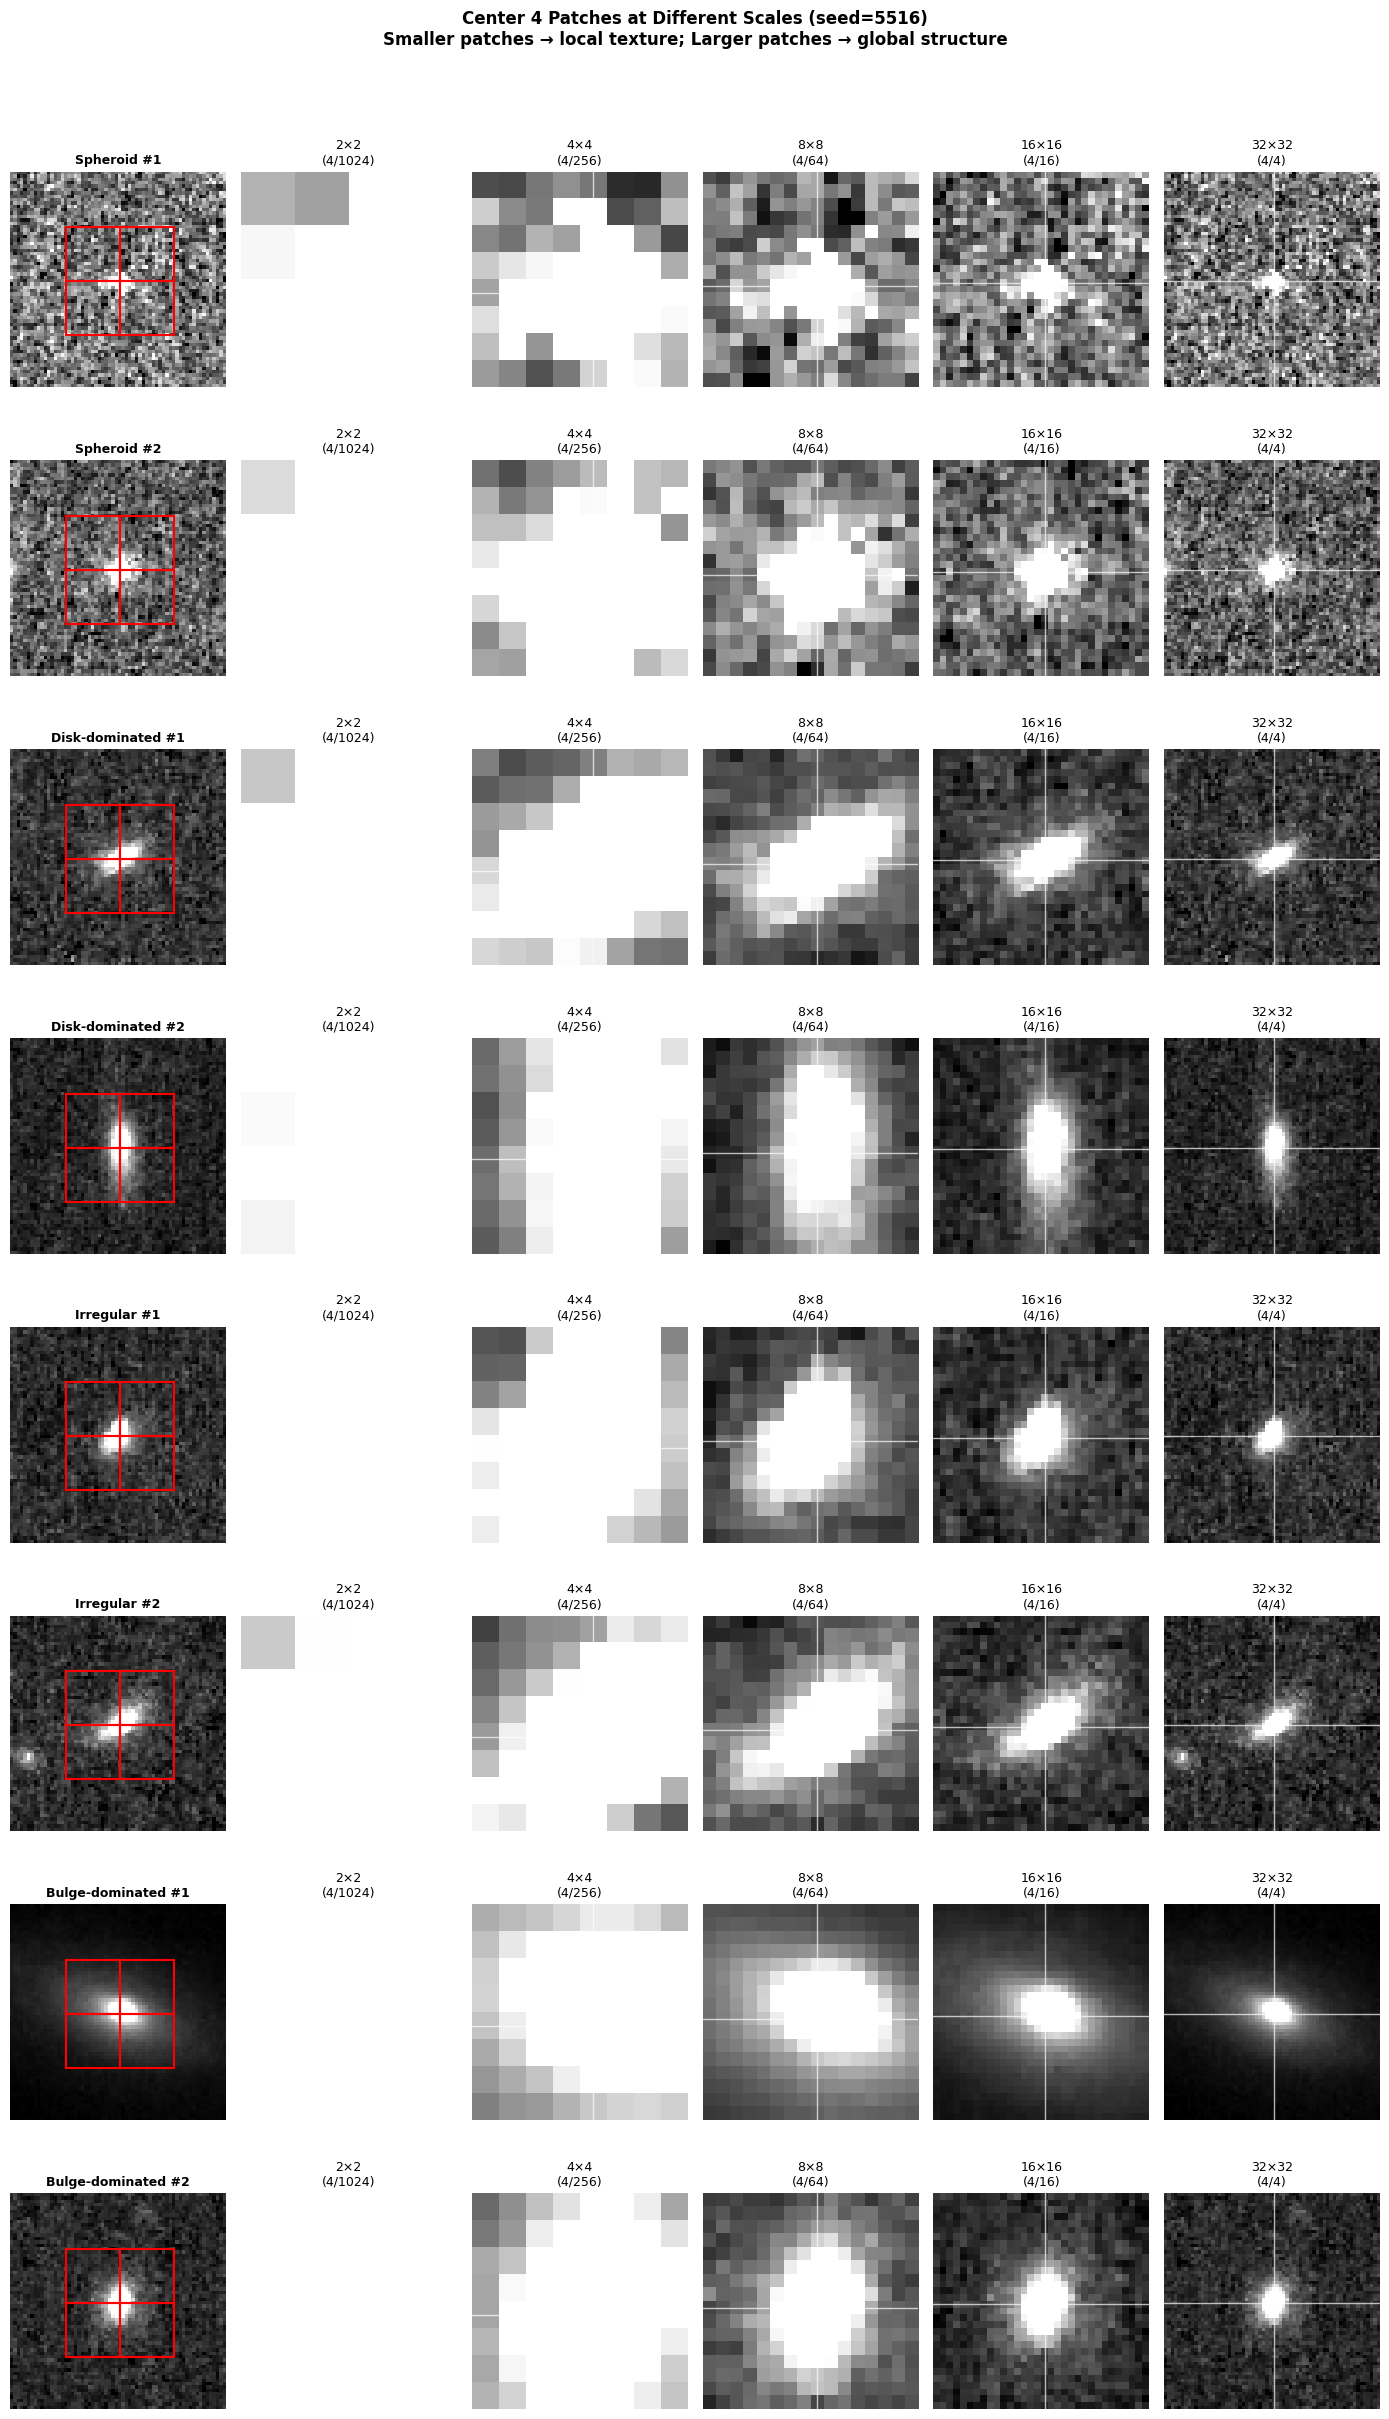


=== Patch Tokenization Info ===
  2×2 patches → 1024 total tokens, center 4 cover 4×4 = 16 pixels
  4×4 patches → 256 total tokens, center 4 cover 8×8 = 64 pixels
  8×8 patches → 64 total tokens, center 4 cover 16×16 = 256 pixels
  16×16 patches → 16 total tokens, center 4 cover 32×32 = 1024 pixels
  32×32 patches → 4 total tokens, center 4 cover 64×64 = 4096 pixels


In [13]:
# Visualize the 4 CENTER PATCHES after tokenization at different patch sizes
# For a 64x64 image with patch_size P, there are (64/P)x(64/P) patches
# The center 4 patches form a 2x2 grid around the image center

def get_center_4_patches(img, patch_size):
    """Extract the center 4 patches (2x2 grid) from tokenized image."""
    h, w = img.shape[:2]
    n_patches_h = h // patch_size
    n_patches_w = w // patch_size
    
    # Center patch indices (the 2x2 grid in the middle)
    center_h = n_patches_h // 2
    center_w = n_patches_w // 2
    
    patches = []
    for i in range(center_h - 1, center_h + 1):  # 2 rows
        for j in range(center_w - 1, center_w + 1):  # 2 cols
            if 0 <= i < n_patches_h and 0 <= j < n_patches_w:
                patch = img[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size]
                patches.append(patch)
    
    return patches, (center_h, center_w)


def plot_center_4_patches(data, n_samples_per_class=1, patch_sizes=[8, 16, 32], seed=None):
    """Plot center 4 patches for random samples from each class.
    
    Args:
        data: Data dictionary
        n_samples_per_class: Number of random samples per morphology class
        patch_sizes: List of patch sizes to visualize
        seed: Random seed (None for random)
    """
    if seed is None:
        seed = np.random.randint(0, 10000)
    print(f"Random seed: {seed}")
    
    n_rows = 4 * n_samples_per_class  # 4 classes × n_samples
    fig, axes = plt.subplots(n_rows, len(patch_sizes) + 1, figsize=(14, 3*n_rows))
    
    if n_rows == 1:
        axes = axes.reshape(1, -1)
    
    row_idx = 0
    for label, name in LABEL_NAMES.items():
        # Get random samples for this class
        indices = get_class_samples(data, label, n_samples=n_samples_per_class, 
                                    delta_threshold=0.3, snr_min=5, seed=seed + label)
        
        for sample_idx, idx in enumerate(indices):
            img = data['images'][idx]
            
            # Center crop and normalize
            img_cropped = normalize_image(img, crop_size=64)
            h, w = img_cropped.shape
            
            # First column: Full 64x64 image with center 4 patches highlighted
            axes[row_idx, 0].imshow(img_cropped, cmap='gray')
            sample_label = f"{name}" if n_samples_per_class == 1 else f"{name} #{sample_idx+1}"
            axes[row_idx, 0].set_title(sample_label, fontsize=9, fontweight='bold')
            axes[row_idx, 0].axis('off')
            
            # Highlight center 4 patches (using 16x16 as reference)
            ps_ref = 16
            n_patches = 64 // ps_ref
            center_idx = n_patches // 2
            for i in range(center_idx - 1, center_idx + 1):
                for j in range(center_idx - 1, center_idx + 1):
                    rect = Rectangle((j*ps_ref, i*ps_ref), ps_ref, ps_ref, 
                                     linewidth=1.5, edgecolor='red', facecolor='none')
                    axes[row_idx, 0].add_patch(rect)
            
            # Show center 4 patches for each patch size
            for col, ps in enumerate(patch_sizes):
                patches, _ = get_center_4_patches(img_cropped, ps)
                
                if len(patches) == 4:
                    top_row = np.concatenate([patches[0], patches[1]], axis=1)
                    bottom_row = np.concatenate([patches[2], patches[3]], axis=1)
                    mosaic = np.concatenate([top_row, bottom_row], axis=0)
                else:
                    mosaic = patches[0] if patches else np.zeros((ps, ps))
                
                axes[row_idx, col+1].imshow(mosaic, cmap='gray', vmin=0, vmax=1)
                n_total = (64 // ps) ** 2
                axes[row_idx, col+1].set_title(f"{ps}×{ps}\n(4/{n_total})", fontsize=9)
                axes[row_idx, col+1].axis('off')
                
                # Draw grid lines
                axes[row_idx, col+1].axhline(ps, color='white', linewidth=1, alpha=0.7)
                axes[row_idx, col+1].axvline(ps, color='white', linewidth=1, alpha=0.7)
            
            row_idx += 1
    
    plt.suptitle(f"Center 4 Patches at Different Scales (seed={seed})\n"
                 "Smaller patches → local texture; Larger patches → global structure", 
                 fontsize=12, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("center_4_patches_comparison.png", dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    
    # Print patch counts
    print("\n=== Patch Tokenization Info ===")
    for ps in patch_sizes:
        n = (64 // ps) ** 2
        print(f"  {ps}×{ps} patches → {n} total tokens, center 4 cover {2*ps}×{2*ps} = {(2*ps)**2} pixels")


# ====== Adjustable parameters ======
N_SAMPLES = 2        # Number of samples per class (1-5 recommended)
PATCH_SIZES = [2, 4, 8, 16, 32]  # Patch sizes to compare
SEED = None          # Set to int for reproducibility, None for random

plot_center_4_patches(data, n_samples_per_class=N_SAMPLES, patch_sizes=PATCH_SIZES, seed=SEED)

## 6.6 Per-Image Patch Coverage for 2*r_eff

Calculate for each image: given its Sersic effective radius and a patch size, how many patches are needed to cover 2*r_eff (diameter ~4*r_eff) within the 64x64 image.

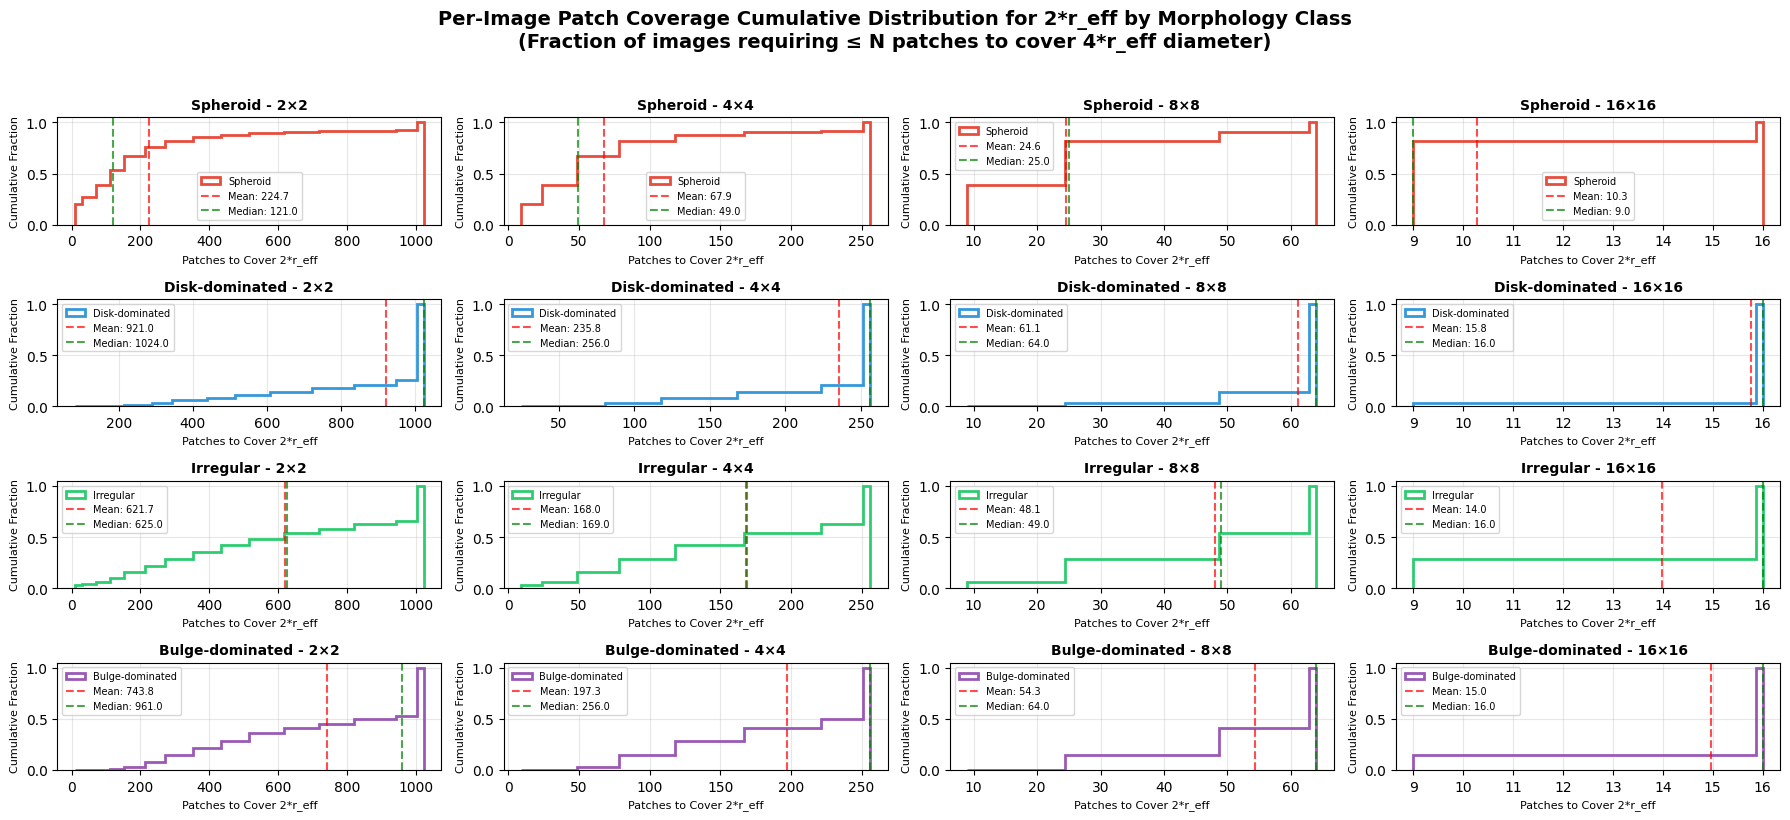


=== Per-Image Patch Coverage for 2*r_eff by Morphology Class ===

Spheroid:
Patch Size Mean Coverage Median Coverage Max Coverage Min Coverage N Images
-------------------------------------------------------------------------------------
         2        224.7           121.0         1024            9     3675
         4         67.9            49.0          256            9     3675
         8         24.6            25.0           64            9     3675
        16         10.3             9.0           16            9     3675

Disk-dominated:
Patch Size Mean Coverage Median Coverage Max Coverage Min Coverage N Images
-------------------------------------------------------------------------------------
         2        921.0          1024.0         1024           81     2033
         4        235.8           256.0          256           25     2033
         8         61.1            64.0           64            9     2033
        16         15.8            16.0           16     

In [14]:
# Calculate per-image patch coverage for 2*r_eff
# For each image, given r_eff and patch size, compute number of patches needed to cover 2*r_eff

def calculate_patch_coverage_for_2reff(r_eff_pix, patch_size, image_size=64):
    """Calculate number of patches needed to cover 2*r_eff diameter.
    
    Assuming patches are cut with galaxy center as patch center (patch boundaries start from galaxy center).
    This simulates the ideal case where galaxy is perfectly centered on a patch.
    
    Args:
        r_eff_pix: Effective radius in pixels
        patch_size: Patch size in pixels
        image_size: Image size (assumed square)
    
    Returns:
        Number of patches needed (minimum 1, capped by total patches in image)
    """
    # Radius to cover: 2 * r_eff (diameter = 4 * r_eff)
    radius_to_cover = 2 * r_eff_pix  # pixels
    
    # Since galaxy center = patch center, patch boundaries are at ±patch_size/2, ±3*patch_size/2, etc.
    # To cover radius r, we need patch boundaries to extend at least to r
    # The farthest patch boundary needed is at distance r from center
    
    # Number of patch boundaries needed on each side
    # patch boundaries are at: patch_size/2, 3*patch_size/2, 5*patch_size/2, ...
    # We need the farthest boundary >= radius_to_cover
    n_boundaries_per_side = np.ceil(radius_to_cover / (patch_size / 2))
    
    # Total patches along one dimension: 2 * n_boundaries_per_side + 1 (including center)
    n_patches_1d = 2 * n_boundaries_per_side + 1
    
    # Total patches needed (square coverage)
    n_patches_total = int(n_patches_1d ** 2)
    
    # Cap by maximum patches in image
    max_patches_in_image = (image_size // patch_size) ** 2
    n_patches_total = min(n_patches_total, max_patches_in_image)
    
    # Minimum 1 patch (the center patch)
    n_patches_total = max(n_patches_total, 1)
    
    return n_patches_total

# Compute for all images and patch sizes, grouped by morphology label
patch_sizes = [2, 4, 8, 16]
coverage_data_by_label = {label: {ps: [] for ps in patch_sizes} for label in LABEL_NAMES.keys()}

# Get valid data (finite r_eff > 0)
valid_mask = np.isfinite(data['radius_sersic']) & (data['radius_sersic'] > 0)
radii_pix = radius_to_pixels(data['radius_sersic'][valid_mask])
morph_flags = data['morph_flag'][valid_mask]

for label in LABEL_NAMES.keys():
    label_mask = morph_flags == label
    label_radii = radii_pix[label_mask]
    
    for ps in patch_sizes:
        for r_eff in label_radii:
            coverage = calculate_patch_coverage_for_2reff(r_eff, ps)
            coverage_data_by_label[label][ps].append(coverage)

# Convert to numpy arrays
for label in LABEL_NAMES.keys():
    for ps in patch_sizes:
        coverage_data_by_label[label][ps] = np.array(coverage_data_by_label[label][ps])

# Visualization: cumulative histograms of coverage per patch size and label
n_labels = len(LABEL_NAMES)
fig, axes = plt.subplots(n_labels, len(patch_sizes), figsize=(18, 2*n_labels))

for row, (label, name) in enumerate(LABEL_NAMES.items()):
    for col, ps in enumerate(patch_sizes):
        ax = axes[row, col]
        coverages = coverage_data_by_label[label][ps]
        
        if len(coverages) > 0:
            ax.hist(coverages, bins=50, density=True, cumulative=True, histtype='step', 
                    linewidth=2, color=LABEL_COLORS[label], label=f'{name}')
            ax.set_title(f"{name} - {ps}×{ps}", fontsize=10, fontweight='bold')
            ax.set_xlabel("Patches to Cover 2*r_eff", fontsize=8)
            ax.set_ylabel("Cumulative Fraction", fontsize=8)
            ax.grid(True, alpha=0.3)
            
            # Add statistics as text
            mean_cov = np.mean(coverages)
            median_cov = np.median(coverages)
            ax.axvline(mean_cov, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_cov:.1f}')
            ax.axvline(median_cov, color='green', linestyle='--', alpha=0.7, label=f'Median: {median_cov:.1f}')
            ax.legend(fontsize=7)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f"{name} - {ps}×{ps}", fontsize=10)

plt.suptitle("Per-Image Patch Coverage Cumulative Distribution for 2*r_eff by Morphology Class\n(Fraction of images requiring ≤ N patches to cover 4*r_eff diameter)", 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("per_image_patch_coverage_2reff_by_label.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

# Print summary statistics by label
print("\n=== Per-Image Patch Coverage for 2*r_eff by Morphology Class ===")
for label, name in LABEL_NAMES.items():
    print(f"\n{name}:")
    print(f"{'Patch Size':<10} {'Mean Coverage':<12} {'Median Coverage':<15} {'Max Coverage':<12} {'Min Coverage':<12} {'N Images':<8}")
    print("-" * 85)
    for ps in patch_sizes:
        coverages = coverage_data_by_label[label][ps]
        if len(coverages) > 0:
            print(f"{ps:>10} {np.mean(coverages):>12.1f} {np.median(coverages):>15.1f} {np.max(coverages):>12.0f} {np.min(coverages):>12.0f} {len(coverages):>8}")
        else:
            print(f"{ps:>10} {'N/A':>12} {'N/A':>15} {'N/A':>12} {'N/A':>12} {0:>8}")

print(f"\nNote: Coverage is capped by total patches in 64x64 image")

## 7. Summary Statistics

Key findings about disk-dominated vs irregular classification ambiguity.

In [15]:
# Compute overlap between classes based on effective radius
print("=== Analysis: Why Disk-dominated and Irregular are ill-defined ===\n")

# 1. Delta distribution comparison
print("1. Classification Uncertainty (delta) by Class:")
for label, name in LABEL_NAMES.items():
    mask = (data['morph_flag'] == label) & np.isfinite(data['delta'])
    deltas = data['delta'][mask]
    print(f"   {name:15s}: mean δ = {np.mean(deltas):.3f}, std = {np.std(deltas):.3f}")

# 2. Physical property overlap
print("\n2. Effective Radius Overlap (IoU-style metric):")
def compute_histogram_overlap(data1, data2, bins=50):
    """Compute overlap between two distributions."""
    # Combine ranges
    all_data = np.concatenate([data1, data2])
    bin_edges = np.linspace(np.min(all_data), np.max(all_data), bins + 1)
    
    hist1, _ = np.histogram(data1, bins=bin_edges, density=True)
    hist2, _ = np.histogram(data2, bins=bin_edges, density=True)
    
    # Overlap is minimum of the two at each bin
    overlap = np.sum(np.minimum(hist1, hist2)) * (bin_edges[1] - bin_edges[0])
    return overlap

# Compare all pairs (convert to pixels for consistency)
pairs = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
for l1, l2 in pairs:
    mask1 = (data['morph_flag'] == l1) & np.isfinite(data['radius_sersic']) & (data['radius_sersic'] > 0)
    mask2 = (data['morph_flag'] == l2) & np.isfinite(data['radius_sersic']) & (data['radius_sersic'] > 0)
    
    r1 = radius_to_pixels(data['radius_sersic'][mask1])  # Convert to pixels
    r2 = radius_to_pixels(data['radius_sersic'][mask2])  # Convert to pixels
    
    if len(r1) > 0 and len(r2) > 0:
        overlap = compute_histogram_overlap(r1, r2)
        print(f"   {LABEL_NAMES[l1]:15s} vs {LABEL_NAMES[l2]:15s}: {overlap:.2%}")

print("\n3. Key Insight:")
print("   High overlap between Disk-dominated and Irregular suggests these classes")
print("   may not be well-separated by effective radius alone. Visual inspection")
print("   of low-confidence samples (high delta) shows morphological ambiguity.")

=== Analysis: Why Disk-dominated and Irregular are ill-defined ===

1. Classification Uncertainty (delta) by Class:
   Spheroid       : mean δ = 0.409, std = 0.254
   Disk-dominated : mean δ = 0.356, std = 0.245
   Irregular      : mean δ = 0.853, std = 0.208
   Bulge-dominated: mean δ = 0.390, std = 0.254

2. Effective Radius Overlap (IoU-style metric):
   Spheroid        vs Disk-dominated : 26.01%
   Spheroid        vs Irregular      : 72.88%
   Spheroid        vs Bulge-dominated: 34.67%
   Disk-dominated  vs Irregular      : 58.83%
   Disk-dominated  vs Bulge-dominated: 71.32%
   Irregular       vs Bulge-dominated: 86.93%

3. Key Insight:
   High overlap between Disk-dominated and Irregular suggests these classes
   may not be well-separated by effective radius alone. Visual inspection
   of low-confidence samples (high delta) shows morphological ambiguity.


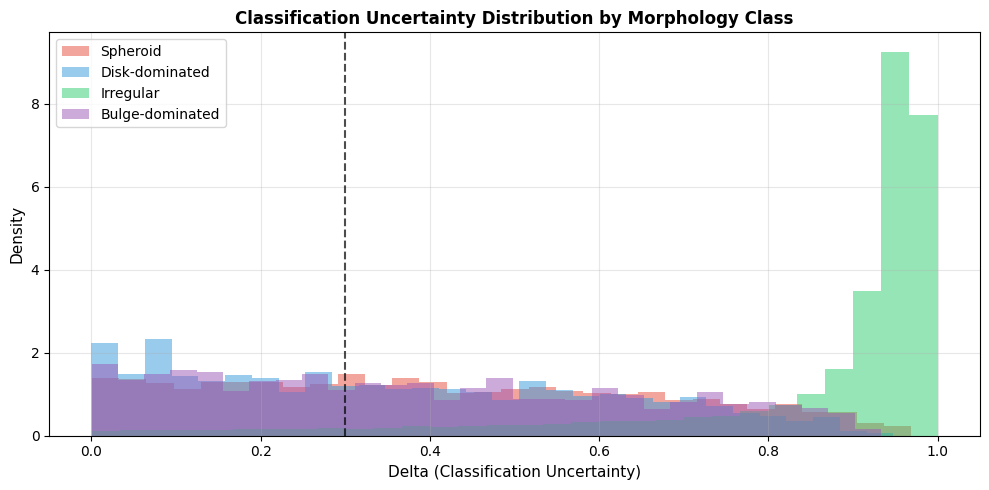

In [16]:
# Visualize delta distribution comparison
fig, ax = plt.subplots(figsize=(10, 5))

for label, name in LABEL_NAMES.items():
    mask = (data['morph_flag'] == label) & np.isfinite(data['delta'])
    deltas = data['delta'][mask]
    ax.hist(deltas, bins=30, alpha=0.5, label=f"{name}", color=LABEL_COLORS[label], density=True)

ax.set_xlabel("Delta (Classification Uncertainty)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Classification Uncertainty Distribution by Morphology Class", fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.axvline(0.3, color='black', linestyle='--', alpha=0.7, label='Typical threshold')

plt.tight_layout()
plt.savefig("delta_distribution_by_class.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

In [17]:
// ...existing code...
# 新增 cell：72x72 图像，6x6 patch 网格示例（放到 notebook 最后）
PATCH_SIZE = 6
CROP_SIZE_72 = 72
N_EXAMPLES_PER_CLASS = 3

classes = sorted(LABEL_NAMES.keys())

fig, axes = plt.subplots(len(classes), 3, figsize=(12, 3*len(classes)))
for row, label in enumerate(classes):
    # 尝试获取高质量样本；不足时回退到随机或重复
    try:
        idxs = get_class_samples(data, label, n_samples=N_EXAMPLES_PER_CLASS, delta_threshold=0.3, snr_min=5, seed=42)
    except Exception:
        idxs = np.where((data['morph_flag']==label) & np.isfinite(data['snr']))[0]
        if len(idxs)==0: idxs = [0]
    # 如果样本数不足，则重复最后一个索引以填满列
    if len(idxs) < N_EXAMPLES_PER_CLASS:
        idxs = list(idxs) + [idxs[-1]]*(N_EXAMPLES_PER_CLASS - len(idxs))
    for col in range(3):
        ax = axes[row, col]
        sel_idx = int(idxs[min(col, len(idxs)-1)])
        img = data['images'][sel_idx]
        # 中心裁剪到 72x72（若图像更大）
        if img.shape[0] > CROP_SIZE_72:
            img_c = center_crop(img, crop_size=CROP_SIZE_72)
        else:
            img_c = img.copy()
        img_norm = normalize_image(img_c, percentile_low=1, percentile_high=99, crop_size=None)
        if col == 0:
            ax.imshow(img_norm, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f"{LABEL_NAMES[label]} — original", fontsize=9)
        elif col == 1:
            ax.imshow(img_norm, cmap='gray', vmin=0, vmax=1)
            # overlay 6x6 grid
            for i in range(0, CROP_SIZE_72+1, PATCH_SIZE):
                ax.axhline(i, color='red', linewidth=0.8, alpha=0.8)
                ax.axvline(i, color='red', linewidth=0.8, alpha=0.8)
            ax.set_title(f"{PATCH_SIZE}×{PATCH_SIZE} grid on {CROP_SIZE_72}×{CROP_SIZE_72}", fontsize=9)
        else:
            # 展示提取的 patch mosaic
            n_h = CROP_SIZE_72 // PATCH_SIZE
            n_w = n_h
            gap = 1
            mosaic_h = n_h * (PATCH_SIZE + gap) - gap
            mosaic_w = n_w * (PATCH_SIZE + gap) - gap
            mosaic = np.ones((mosaic_h, mosaic_w), dtype=np.float32) * 0.5
            for i in range(n_h):
                for j in range(n_w):
                    patch = img_norm[i*PATCH_SIZE:(i+1)*PATCH_SIZE, j*PATCH_SIZE:(j+1)*PATCH_SIZE]
                    y0 = i * (PATCH_SIZE + gap)
                    x0 = j * (PATCH_SIZE + gap)
                    mosaic[y0:y0+PATCH_SIZE, x0:x0+PATCH_SIZE] = patch
            ax.imshow(mosaic, cmap='gray', vmin=0, vmax=1)
            ax.set_title(f"Extracted patches ({PATCH_SIZE}×{PATCH_SIZE})", fontsize=9)
        ax.axis('off')

plt.suptitle(f"Examples: {PATCH_SIZE}×{PATCH_SIZE} patching on {CROP_SIZE_72}×{CROP_SIZE_72} images", fontsize=12)
plt.tight_layout(rect=[0,0,1,0.96])
outp = os.path.join(POSTER_DIR, f'patch{PATCH_SIZE}x{PATCH_SIZE}_{CROP_SIZE_72}x{CROP_SIZE_72}_examples.png')
plt.savefig(outp, dpi=300, transparent=True)
print(f"Saved → {outp}")
plt.show()
// ...existing code...

SyntaxError: invalid syntax (3097190957.py, line 1)